In [2]:
import sys
!{sys.executable} -m pip install sktime transformers


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: C:\Users\10098\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip


In [3]:
import pyarrow.parquet as pq
import pandas as pd
import numpy as np

table = pq.read_table("train-00000-of-00001.parquet")
data = table.to_pydict()

df = pd.DataFrame({
    "id": data["id"],
    "timestamp": data["timestamp"],
    "target": data["target"]
})

print(df.head())
print(df.shape)

        id                                          timestamp  \
0  T000000  [2012-01-01 01:00:00, 2012-01-01 02:00:00, 201...   
1  T000001  [2012-01-01 01:00:00, 2012-01-01 02:00:00, 201...   
2  T000002  [2012-01-01 01:00:00, 2012-01-01 02:00:00, 201...   
3  T000003  [2012-01-01 01:00:00, 2012-01-01 02:00:00, 201...   
4  T000004  [2012-01-01 01:00:00, 2012-01-01 02:00:00, 201...   

                                              target  
0  [14.0, 18.0, 21.0, 20.0, 22.0, 20.0, 20.0, 20....  
1  [69.0, 92.0, 96.0, 92.0, 91.0, 92.0, 91.0, 92....  
2  [234.0, 312.0, 312.0, 312.0, 312.0, 187.0, 138...  
3  [415.0, 556.0, 560.0, 443.0, 346.0, 340.0, 376...  
4  [215.0, 292.0, 272.0, 213.0, 190.0, 178.0, 199...  
(321, 3)


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sktime.forecasting.ttm import TinyTimeMixerForecaster

In [10]:
sample_idx = 0

series = np.array(df.loc[sample_idx, "target"], dtype=float)
timestamps = pd.to_datetime(df.loc[sample_idx, "timestamp"])

order = np.argsort(timestamps)
timestamps = timestamps[order]
series = series[order]

time_index = pd.DatetimeIndex(timestamps)

freq = pd.infer_freq(time_index)

if freq is None:
    freq = "H"

time_index = pd.date_range(start=time_index[0], periods=len(time_index), freq=freq)

y = pd.Series(series, index=time_index)

split_idx = int(len(y) * 0.8)
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print("freq:", freq)
print("train length:", len(y_train))
print("test length:", len(y_test))
print(y.head())

freq: h
train length: 21043
test length: 5261
2012-01-01 01:00:00    14.0
2012-01-01 02:00:00    18.0
2012-01-01 03:00:00    21.0
2012-01-01 04:00:00    20.0
2012-01-01 05:00:00    22.0
Freq: h, dtype: float64


In [11]:
scaler = StandardScaler()

y_train_scaled = pd.Series(
    scaler.fit_transform(y_train.values.reshape(-1, 1)).ravel(),
    index=y_train.index
)

y_test_scaled = pd.Series(
    scaler.transform(y_test.values.reshape(-1, 1)).ravel(),
    index=y_test.index
)

print(y_train_scaled.head())
print(y_test_scaled.head())

2012-01-01 01:00:00   -0.408180
2012-01-01 02:00:00   -0.241821
2012-01-01 03:00:00   -0.117051
2012-01-01 04:00:00   -0.158641
2012-01-01 05:00:00   -0.075462
Freq: h, dtype: float64
2014-05-26 20:00:00   -0.699309
2014-05-26 21:00:00   -0.616129
2014-05-26 22:00:00   -0.574539
2014-05-26 23:00:00   -0.075462
2014-05-27 00:00:00   -0.158641
Freq: h, dtype: float64


In [12]:
forecaster = TinyTimeMixerForecaster(
    model_path="ibm-granite/granite-timeseries-ttm-r2",
    revision="main",
    fit_strategy="zero-shot",
    use_source_package=True
)

forecaster.fit(y_train_scaled, fh=[1])

print("TTM forecaster ready")

TTM forecaster ready


In [13]:
orig_forward = forecaster.model.forward

def patched_forward(*args, **kwargs):
    if "observed_mask" in kwargs and "past_observed_mask" not in kwargs:
        kwargs["past_observed_mask"] = kwargs.pop("observed_mask")
    if "future_mask" in kwargs and "future_observed_mask" not in kwargs:
        kwargs["future_observed_mask"] = kwargs.pop("future_mask")
    return orig_forward(*args, **kwargs)

forecaster.model.forward = patched_forward

print("forward patch applied")

forward patch applied


In [16]:
import torch

preds_scaled = []

model = forecaster.model
model.eval()

device = next(model.parameters()).device
context_length = model.config.context_length
prediction_length = 1

history = list(y_train_scaled.values)

for val in y_test_scaled.values:
    context = np.array(history[-context_length:], dtype=np.float32)

    past_values = torch.tensor(context, dtype=torch.float32).view(1, context_length, 1).to(device)
    past_observed_mask = torch.ones_like(past_values).to(device)

    with torch.no_grad():
        outputs = model(
            past_values=past_values,
            past_observed_mask=past_observed_mask,
            return_dict=True
        )

    pred_scaled = outputs.prediction_outputs.detach().cpu().numpy()
    pred_next_scaled = float(pred_scaled[0, 0, 0])
    preds_scaled.append(pred_next_scaled)

    history.append(val)

preds_scaled = np.array(preds_scaled)
preds = scaler.inverse_transform(preds_scaled.reshape(-1, 1)).ravel()
trues = y_test.values

print("first 5 predictions:", preds[:5])
print("first 5 true values:", trues[:5])
print("number of test predictions:", len(preds))

first 5 predictions: [10.10100392  9.9416213  11.46015386 10.73834954 22.477718  ]
first 5 true values: [ 7.  9. 10. 22. 20.]
number of test predictions: 5261


In [17]:
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-8))) * 100

mae = mean_absolute_error(trues, preds)
rmse = mean_squared_error(trues, preds) ** 0.5
mape_value = mape(trues, preds)
r2 = r2_score(trues, preds)

result_df = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "MAPE", "R2"],
    "Value": [mae, rmse, mape_value, r2]
})

print(result_df)

  Metric         Value
0    MAE  4.146948e+00
1   RMSE  8.490784e+00
2   MAPE  3.437008e+08
3     R2  8.782002e-01


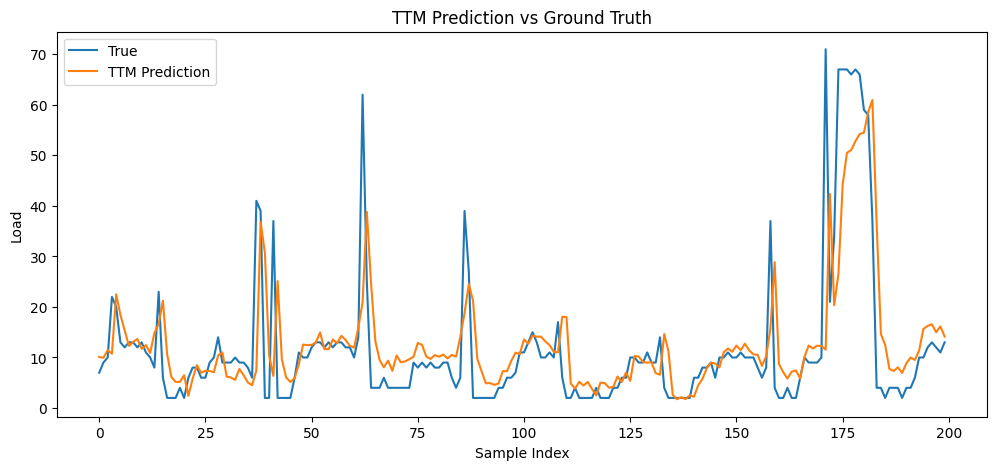

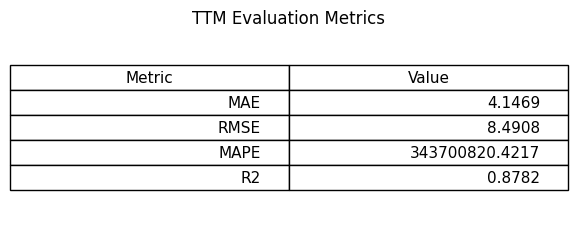

In [18]:
plt.figure(figsize=(12, 5))
plt.plot(trues[:200], label="True")
plt.plot(preds[:200], label="TTM Prediction")
plt.title("TTM Prediction vs Ground Truth")
plt.xlabel("Sample Index")
plt.ylabel("Load")
plt.legend()
plt.savefig("ttm_prediction_plot.png", dpi=300, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(6, 2.5))
ax.axis("off")

table = ax.table(
    cellText=result_df.round(4).values,
    colLabels=result_df.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.5)

plt.title("TTM Evaluation Metrics")
plt.savefig("ttm_metrics_table.png", dpi=300, bbox_inches="tight")
plt.show()